# Econometrics Final Project: Spotify Tracks Popularity Analysis

Student Name: Mohammad Mokhtari  
Student ID: 401102478  

### Abstract
This project investigates the causal effect of acoustic and structural features of music tracks (e.g., energy, tempo, danceability) on their popularity index on Spotify. Using Ordinary Least Squares (OLS) regression, we analyze the impact of these audio features while controlling for the fixed effects of music genres to mitigate Omitted Variable Bias (OVB).

## 1. Importing Libraries

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Data Acquisition
Downloading the Spotify Tracks dataset and loading it into a pandas DataFrame.

In [4]:
print("Downloading dataset...")
path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")

csv_file = path + "/dataset.csv"
df_raw = pd.read_csv(csv_file)

df_raw.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

## 3. Data Cleaning
Preprocessing steps:
1. Drop the redundant index column.
2. Remove missing values.
3. Drop duplicate tracks based on track_id.
4. Convert the boolean explicit variable to integer (0 and 1).

In [16]:
df = df_raw.copy()
print(f"Initial dataset shape: {df.shape}")

df = df.drop(columns=['Unnamed: 0'])    
df = df.dropna()
df = df.drop_duplicates(subset=['track_id'])
df['explicit'] = df['explicit'].astype(int)

print(f"Data cleaning completed. Final dataset shape: {df.shape}")

Initial dataset shape: (114000, 21)
Data cleaning completed. Final dataset shape: (89740, 20)


## 4. Feature Selection
Filtering the dataset to keep only the dependent variable (Y), independent variables (X), and control variables.

In [17]:
features = [
    'track_id', 'popularity', 'danceability', 'energy', 
    'tempo', 'loudness', 'valence', 'explicit', 'track_genre'
]

df_model = df[features].copy()
display(df_model.describe().round(2))

,popularity,danceability,energy,tempo,loudness,valence,explicit
count,89740.00,89740.00,89740.00,89740.00,89740.00,89740.00,89740.00
mean,33.20,0.56,0.63,122.06,-8.50,0.47,0.09
std,20.58,0.18,0.26,30.12,5.22,0.26,0.28
min,0.00,0.00,0.00,0.00,-49.53,0.00,0.00
25%,19.00,0.45,0.46,99.26,-10.32,0.25,0.00
50%,33.00,0.58,0.68,122.01,-7.18,0.46,0.00
75%,49.00,0.69,0.85,140.08,-5.11,0.68,0.00
max,100.00,0.98,1.00,243.37,4.53,1.00,1.00


## 5. Exploratory Data Analysis (EDA)
Before fitting the OLS model, we visualize the distribution of our dependent variable (`popularity`) and the correlation between our independent variables to check for potential multicollinearity intuitively.

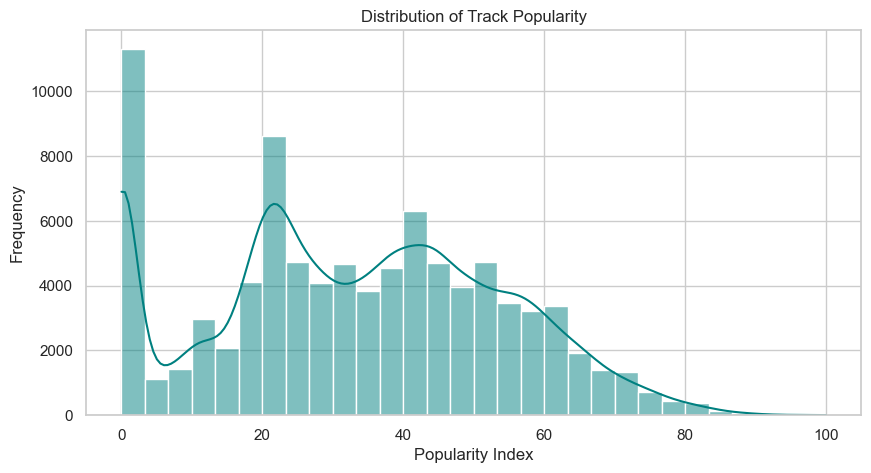

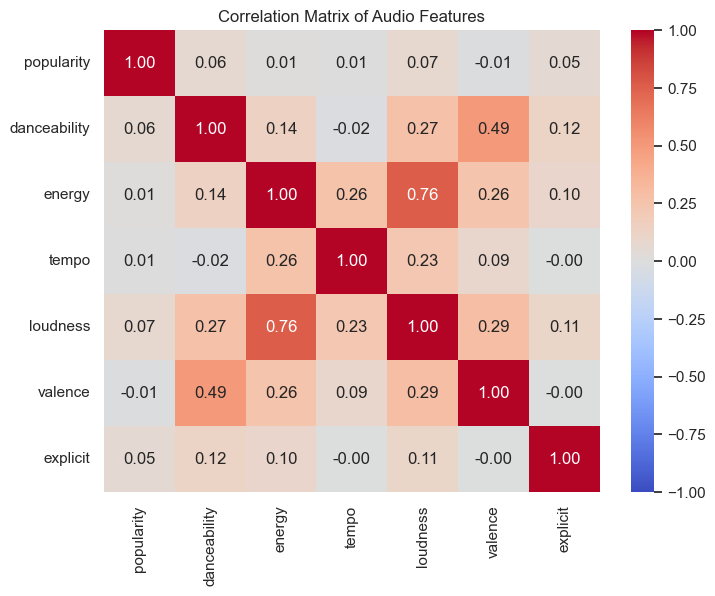

In [18]:
# Distribution of the dependent variable
plt.figure(figsize=(10, 5))
sns.histplot(df_model['popularity'], bins=30, kde=True, color='teal')
plt.title('Distribution of Track Popularity')
plt.xlabel('Popularity Index')
plt.ylabel('Frequency')
plt.show()

# Correlation Matrix Heatmap
numeric_vars = ['popularity', 'danceability', 'energy', 'tempo', 'loudness', 'valence', 'explicit']
corr_matrix = df_model[numeric_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix of Audio Features')
plt.show()

## 6. Multicollinearity Diagnostic (VIF)
While the correlation matrix gives a pairwise overview, the Variance Inflation Factor (VIF) provides a strict econometric test for multicollinearity. A VIF value above 5 (or 10) indicates problematic multicollinearity. 
*Note: We expect some correlation between 'energy' and 'loudness'.*

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Define independent variables for VIF check
X_vif = df_model[['danceability', 'energy', 'tempo', 'loudness', 'valence', 'explicit']]
# Adding a constant is required for correct VIF calculation
X_vif = sm.add_constant(X_vif)

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

display(vif_data.round(2))

,Feature,VIF
0,const,72.38
1,danceability,1.42
2,energy,2.45
3,tempo,1.09
4,loudness,2.53
5,valence,1.40
6,explicit,1.03


## 7. Model Specification and OLS Estimation
Based on the VIF diagnostic, all values are well below the critical threshold of 5. This indicates that multicollinearity is not a severe issue, and we can safely retain all selected variables in our model.

We estimate the OLS model including genre fixed effects (`C(track_genre)`) to control for Omitted Variable Bias (OVB). Additionally, we apply Heteroskedasticity-Consistent (Robust) Standard Errors (HC3) to ensure reliable statistical inference.

In [21]:
import statsmodels.formula.api as smf

# Define the regression formula
# C(track_genre) creates dummy variables for each genre automatically
formula = 'popularity ~ danceability + energy + tempo + loudness + valence + explicit + C(track_genre)'

print("Fitting the OLS model with Genre Fixed Effects...")
model = smf.ols(formula=formula, data=df_model)

# Fit the model with Robust Standard Errors (HC3)
results = model.fit(cov_type='HC3')

# Extracting the results into a clean DataFrame
res_df = pd.DataFrame({
    'Coefficient': results.params,
    'Robust SE': results.bse,
    't-value': results.tvalues,
    'P>|t|': results.pvalues
})

# Filter out the 124 genre dummies to keep the output readable
main_vars = ['Intercept', 'danceability', 'energy', 'tempo', 'loudness', 'valence', 'explicit']
main_results = res_df.loc[res_df.index.isin(main_vars)]

print("\n--- Main OLS Regression Results (with Robust SE) ---")
display(main_results.round(4))

print(f"\nR-squared: {results.rsquared:.4f}")
print(f"Adj. R-squared: {results.rsquared_adj:.4f}")
print(f"Number of observations: {int(results.nobs)}")

Fitting the OLS model with Genre Fixed Effects...

--- Main OLS Regression Results (with Robust SE) ---


,Coefficient,Robust SE,t-value,P>|t|
Intercept,42.2753,0.7143,59.1831,0.0000
danceability,5.7631,0.4729,12.1858,0.0000
energy,-1.8334,0.4393,-4.1731,0.0000
tempo,0.0040,0.0020,1.9733,0.0485
loudness,0.1124,0.0201,5.6010,0.0000
valence,-3.9563,0.3038,-13.0219,0.0000
explicit,2.0471,0.2620,7.8135,0.0000



R-squared: 0.3288
Adj. R-squared: 0.3280
Number of observations: 89740


## 8. Interpretation of OLS Results

The OLS regression model yields an R-squared of 0.3288, meaning our selected audio features and genre fixed effects explain approximately 32.8% of the variance in track popularity. Given the cross-sectional nature of the data and the high number of observations, this is a highly satisfactory explanatory power.

### Key Economic and Behavioral Findings (Ceteris Paribus):
* **Danceability:** Exhibits a strong positive causal effect. A 1-unit increase in danceability increases the popularity index by 5.76 points.
* **Explicit Content:** Explicit tracks are, on average, 2.04 points more popular than clean tracks, indicating a specific listener preference structure.
* **Valence:** Shows a negative coefficient (-3.95). Holding genre and other features constant, tracks with higher valence (happier or more positive tone) tend to have slightly lower popularity compared to darker or sadder tracks.
* **Energy vs. Loudness:** While loudness has a positive effect (0.11), energy shows a negative coefficient (-1.83). This suggests that once the sheer volume (loudness) is controlled for, excessive acoustic energy might slightly penalize a track's mainstream appeal.
* **Tempo:** Has a very marginal positive effect (0.004) and is barely significant at the 5% level (p-value = 0.0485), meaning speed alone is not a primary driver of popularity.

## 9. Conclusion and Project Limitations

### Conclusion
This project successfully identified the causal impact of acoustic features on music popularity. By controlling for track genre (Fixed Effects), we mitigated Omitted Variable Bias (OVB) and extracted the pure behavioral impact of variables like danceability and valence on listener preferences.

### Limitations
1. **Omitted Artist Network Effect:** Although genre was controlled, the exact popularity of the artist prior to the track's release was not available in this dataset. A highly famous artist might inflate a track's popularity regardless of its audio features.
2. **Platform Bias:** The popularity metric is specific to Spotify's algorithm and user base, which may not perfectly generalize to global music consumption across all platforms.